<a href="https://colab.research.google.com/github/Elexandro1978/projeto-an-lise-dados-coursera/blob/main/C%C3%B3pia_de_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Carregando o arquivo (no Colab basta o nome direto dele!)
df = pd.read_csv("/content/sample_data/dadoslimpostcc.csv")

# Exibe as primeiras linhas da sua tabela limpa
df.head()

,Município,URA,Pop \nUrb,Classificação,Tipologia,Tratamento,Local \nTratamento,Disposição Final,Local Disposição Final,Porte do município
0,Abadia dos Dourados,Alto Paranaíba,6.024,Regularizado,AS Regularizado,Galpão de Catadores,no município,AS Regularizado,Uberlândia,Pequeno Porte
1,Abaeté,Alto São Francisco,21.332,Regularizado,AS Regularizado,-,-,AS Regularizado,Bambuí,Medio Porte
2,Abre-Campo,Zona da Mata,8.846,Regularizado,AS Regularizado + UTC Não Regularizada,UTC Não Regularizada,no município,AS Regularizado,Piedade de Ponte Nova,Pequeno Porte
3,Acaiaca,Zona da Mata,3.317,Regularizado,AS Regularizado,-,-,AS Regularizado,Piedade de Ponte Nova,Pequeno Porte
4,Açucena,Leste de Minas,5.848,Regularizado,AS Regularizado,Galpão de Catadores,no município,AS Regularizado,Santana do Paraíso,Pequeno Porte


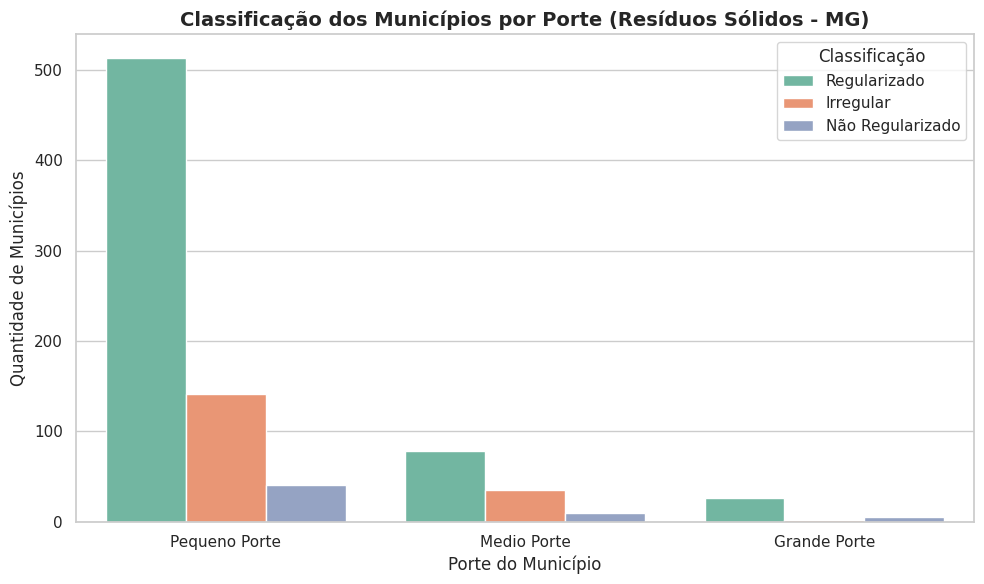

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o tamanho do gráfico
plt.figure(figsize=(10, 6))

# Limpar nomes das colunas para evitar erros de digitação ou espaços invisíveis
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

# Cria o gráfico de barras contando os municípios por Porte e Classificação
sns.countplot(data=df, x='Porte do município', hue='Classificação', palette='Set2')

# Títulos e legendas
plt.title('Classificação dos Municípios por Porte (Resíduos Sólidos - MG)', fontsize=14, fontweight='bold')
plt.xlabel('Porte do Município', fontsize=12)
plt.ylabel('Quantidade de Municípios', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Classificação')

# Mostra o gráfico na tela
plt.tight_layout()
plt.show()

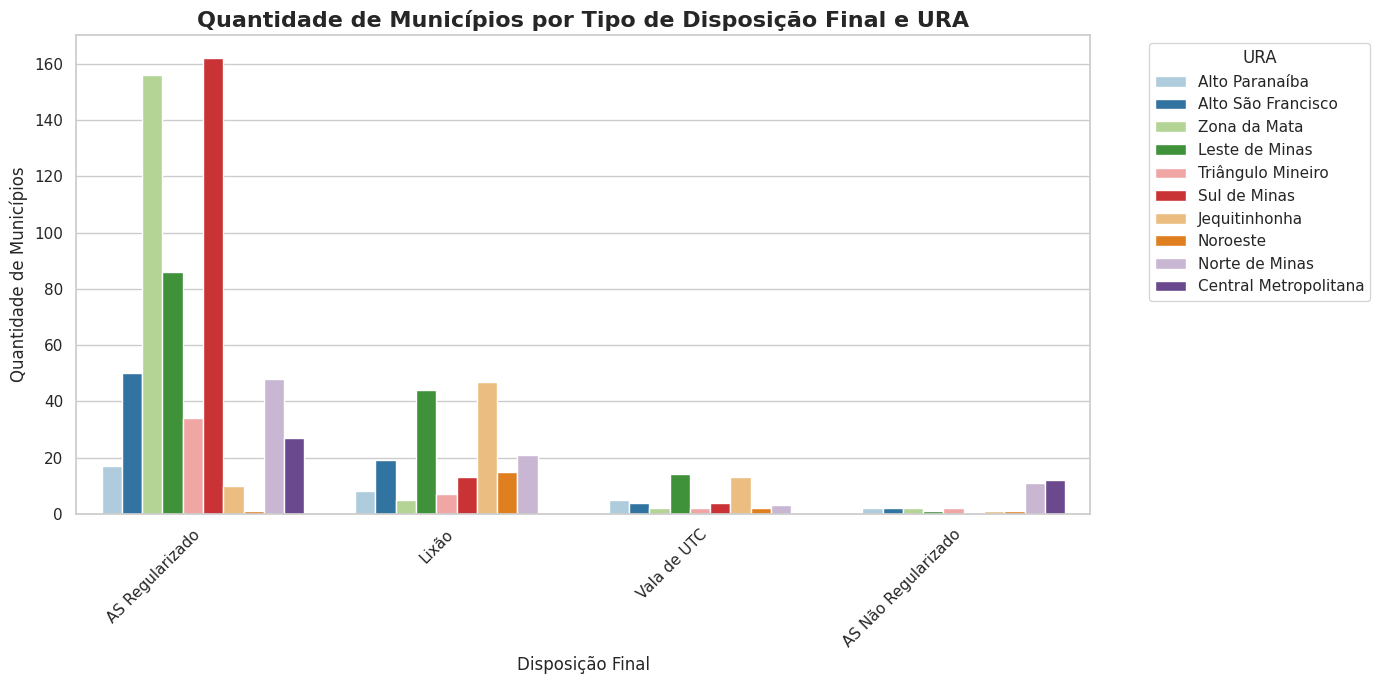

In [ ]:
plt.figure(figsize=(14, 7))

sns.countplot(data=df, x='Disposição Final', hue='URA', palette='Paired')

plt.title('Quantidade de Municípios por Tipo de Disposição Final e URA', fontsize=16, fontweight='bold')
plt.xlabel('Disposição Final', fontsize=12)
plt.ylabel('Quantidade de Municípios', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='URA', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

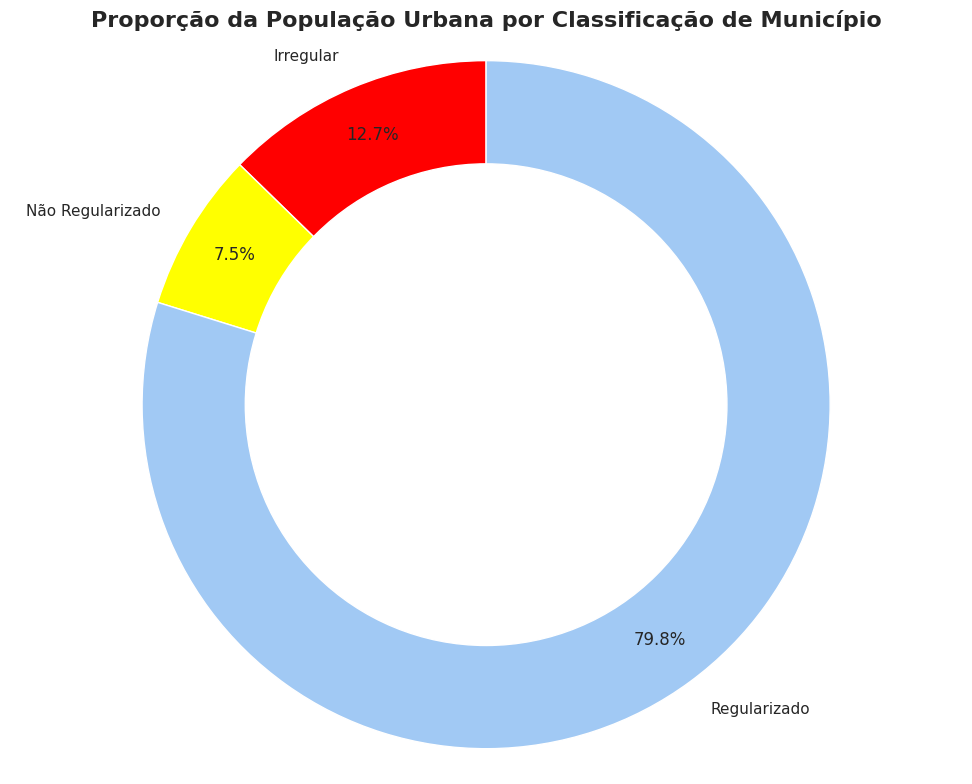

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Limpar e converter 'Pop Urb' para numérico
# Remover pontos de separador de milhar e converter para float
df['Pop Urb'] = df['Pop Urb'].astype(str).str.replace('.', '', regex=False).astype(float)

# Agrupar por 'Classificação' e somar a população urbana
pop_by_classificacao = df.groupby('Classificação')['Pop Urb'].sum()

# Definir as cores personalizadas
# 'Regularizado' pode ser mantido com uma cor padrão ou especificado
colors = {
    'Irregular': 'red',
    'Não Regularizado': 'yellow',
    'Regularizado': sns.color_palette('pastel')[0] # Usando a primeira cor do pastel para 'Regularizado'
}

# Criar uma lista de cores na ordem das classificações
ordered_colors = [colors[c] for c in pop_by_classificacao.index]

# Criar o gráfico de rosca
plt.figure(figsize=(10, 8))

# Gerar o gráfico de pizza (o "donut" será criado com um círculo branco no centro)
plt.pie(pop_by_classificacao, labels=pop_by_classificacao.index, autopct='%1.1f%%', startangle=90,
        pctdistance=0.85, colors=ordered_colors) # Usando as cores ordenadas

# Criar um círculo branco para transformar o gráfico de pizza em um gráfico de rosca
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Título do gráfico
plt.title('Proporção da População Urbana por Classificação de Município', fontsize=16, fontweight='bold')

plt.axis('equal')  # Garante que o círculo seja desenhado como um círculo
plt.tight_layout()
plt.show()